# 08 — Feature Selection

**Stage 7 · narrows the mechanism-informed candidates to a classifier panel**

Apply three independent feature-selection methods to the mechanism-informed candidate
gene set assembled in Stages 4 and 6, and take the genes selected by ≥2 of 3 methods as
the minimal TSPC vs. T-FAP classifier panel.

- **Candidates:** 119-gene pySCENIC × CellRank T-FAP overlap (verified robust to the root-choice sensitivity check in `05b`) + 5 TSPC identity markers (Tppp3, Prg4, Igfbp6, Sema3c, Cd34)
- **Methods:** LASSO (L1 logistic regression), Boruta (all-relevant RF wrapper), XGBoost (gain-importance thresholding) — run independently, each on the full candidate set, with no cross-method or mechanism-derived weighting baked into any individual method
- **Training data:** Harvey 2019 TSPC (266) vs. T-FAP (433) cells (`cell_type` ∈ {TSPC, T-FAP}; the 1,025 Unknown cells and other annotated types are excluded)
- **Optional weighting:** genes targeted by Junb/Jund/Klf9 — the three regulons anchoring most of the 119-gene CellRank overlap (Stage 6) — are flagged as an annotation/tie-breaker on the final panel, not used inside any of the three selection methods, so the three methods stay independent as intended

**Inputs**
- `data/cellrank/pyscenic_cellrank_tfap_overlap.csv` — from `05`
- `data/Harvey_scRNA-seq/harvey2019_processed.h5ad` — from `03`

**Outputs**
- `data/feature_selection/gene_selection_by_method.csv` — all 124 candidates × per-method flags
- `data/feature_selection/final_panel.csv`, `final_panel_annotated.csv` — 44-gene panel (≥2/3 methods)
- `data/feature_selection/core_panel_unanimous.csv` — 23-gene panel (3/3 methods, the Stage 8 primary)
- `figures/feature_selection/method_overlap.png`

**Runs after:** `03`, `05`, `07` · **Feeds:** `09`

**Environment:** analysis env (`environments/analysis.txt`). Run with the working directory set to `scripts/ipynb/` — every path below is relative to it.

---

**Known limitations carried forward (not re-litigated here, see `docs/progress.md`):** Harvey 2019 is a single pooled sample per condition with no biological replicates, so cross-validation folds here are cell-level splits within one sample, not sample-level generalisation — Stage 8's validation on the independent Cherief 2023 dataset is the real generalisation test. Harvey's T-FAP cluster was also excluded by the original paper's own authors from their trajectory analysis; T-FAP here is this project's own annotation (Stage 1c), not an established literature cell state.


## 0. Setup

Imports, paths and output directories.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

ROOT = Path('../..')
DATA_CR = ROOT / 'data' / 'cellrank'
DATA_HV = ROOT / 'data' / 'Harvey_scRNA-seq'
OUT_DATA = ROOT / 'data' / 'feature_selection'
OUT_FIG = ROOT / 'figures' / 'feature_selection'
OUT_DATA.mkdir(exist_ok=True)
OUT_FIG.mkdir(exist_ok=True)

RANDOM_STATE = 0

## 1. Candidate gene panel

119 T-FAP genes (pySCENIC × CellRank overlap) + 5 TSPC markers. The Junb/Jund/Klf9-target flag is computed here for later use as an annotation on the final panel — it plays no role in candidate selection or in any of the three methods below.

In [2]:
overlap = pd.read_csv(DATA_CR / 'pyscenic_cellrank_tfap_overlap.csv')
tfap_genes = overlap['gene'].tolist()
tspc_markers = ['Tppp3', 'Prg4', 'Igfbp6', 'Sema3c', 'Cd34']

candidates = sorted(set(tfap_genes) | set(tspc_markers))
print(f'{len(tfap_genes)} T-FAP candidate genes + {len(tspc_markers)} TSPC markers -> {len(candidates)} unique candidates')

priority_tfs = ('Junb', 'Jund', 'Klf9')
priority_targets = set(
    overlap.loc[overlap['regulons'].apply(lambda r: any(tf in r for tf in priority_tfs)), 'gene']
)
print(f'{len(priority_targets)} of the 119 T-FAP genes are targets of Junb/Jund/Klf9')

119 T-FAP candidate genes + 5 TSPC markers -> 124 unique candidates
75 of the 119 T-FAP genes are targets of Junb/Jund/Klf9


## 2. Load Harvey 2019 training data

Uses `adata.raw` (log1p-normalised counts, non-negative) rather than the processed `.X` (z-scored PCA input, has negative values from scaling on a much larger HVG set) — log-normalised expression is the standard, more interpretable input for LASSO coefficients and tree-based importances. Subset to the 124 candidate genes and to TSPC/T-FAP cells only.

In [3]:
adata = sc.read_h5ad(DATA_HV / 'harvey2019_processed.h5ad')
adata = adata.raw.to_adata()

mask = adata.obs['cell_type'].isin(['TSPC', 'T-FAP'])
adata = adata[mask, candidates].copy()
print(adata.obs['cell_type'].value_counts())

X = adata.X.toarray() if hasattr(adata.X, 'toarray') else np.asarray(adata.X)
X = pd.DataFrame(X, columns=candidates, index=adata.obs_names)
y = (adata.obs['cell_type'] == 'T-FAP').astype(int).values  # 1 = T-FAP, 0 = TSPC
print(f'{X.shape[0]} cells x {X.shape[1]} genes; {int(y.sum())} T-FAP / {int((y == 0).sum())} TSPC')

cell_type
T-FAP    433
TSPC     266
Name: count, dtype: int64
699 cells x 124 genes; 433 T-FAP / 266 TSPC


## 3. Method 1 — LASSO (L1-penalised logistic regression)

Features standardised (mean 0, unit variance) since L1 penalty magnitude is scale-dependent. `class_weight='balanced'` corrects for the 266:433 TSPC:T-FAP imbalance. Regularisation strength picked by 10-fold CV on ROC-AUC.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = LogisticRegressionCV(
    Cs=20, cv=10, penalty='l1', solver='liblinear', scoring='roc_auc',
    class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE, n_jobs=-1,
)
lasso.fit(X_scaled, y)

lasso_coef = pd.Series(lasso.coef_[0], index=candidates)
lasso_genes = lasso_coef[lasso_coef != 0].index.tolist()
print(f'LASSO: C={lasso.C_[0]:.4f}, {len(lasso_genes)} genes with nonzero coefficient (of {len(candidates)})')
lasso_coef[lasso_coef != 0].sort_values(key=np.abs, ascending=False)

c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-le

LASSO: C=1.6238, 65 genes with nonzero coefficient (of 124)


C3         2.186477
Tppp3     -1.616024
Slfn5      1.537495
Sema3c     1.498520
Igfbp7    -1.214239
             ...   
Adamts1   -0.025025
Mycbp2    -0.024328
Slc1a3     0.019194
Slc16a1   -0.015190
Myc        0.013045
Length: 65, dtype: float64

## 4. Method 2 — Boruta (all-relevant random forest wrapper)

Boruta compares each real feature's importance against shadow (permuted) copies of itself across iterations, confirming a feature only if it consistently beats the best shadow feature — a stricter, all-relevant standard than a single RF importance ranking. Only `support_` (confirmed) genes count as selected; tentative genes are reported but not counted.

In [5]:
rf = RandomForestClassifier(
    n_estimators=500, class_weight='balanced', max_depth=5, random_state=RANDOM_STATE, n_jobs=-1,
)
boruta = BorutaPy(rf, n_estimators='auto', max_iter=100, random_state=RANDOM_STATE, verbose=0)
boruta.fit(X.values, y)

boruta_genes = X.columns[boruta.support_].tolist()
boruta_tentative = X.columns[boruta.support_weak_].tolist()
print(f'Boruta: {len(boruta_genes)} confirmed genes, {len(boruta_tentative)} tentative (not counted as selected)')
print('Tentative:', ', '.join(boruta_tentative) if boruta_tentative else '(none)')

Boruta: 52 confirmed genes, 2 tentative (not counted as selected)
Tentative: Cd302, Gdf10


## 5. Method 3 — XGBoost (gain importance, `SelectFromModel`)

`scale_pos_weight` corrects for the class imbalance (parallel to `class_weight='balanced'` above). Shallow trees (max_depth=3) and subsampling limit overfitting given n=699. Genes are selected if their gain-based importance exceeds the mean importance across all 124 candidates — an automatic, non-arbitrary threshold analogous to LASSO's CV-picked C and Boruta's shadow-feature test.

In [6]:
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
xgb = XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1,
)
xgb.fit(X, y)

selector = SelectFromModel(xgb, threshold='mean', prefit=True)
xgb_genes = X.columns[selector.get_support()].tolist()
xgb_importance = pd.Series(xgb.feature_importances_, index=candidates).sort_values(ascending=False)
print(f'XGBoost: {len(xgb_genes)} genes with above-mean gain importance (of {len(candidates)})')
xgb_importance[xgb_importance.index.isin(xgb_genes)]

XGBoost: 33 genes with above-mean gain importance (of 124)


C3          0.164997
Slfn5       0.074369
Steap4      0.065922
C1ra        0.056506
Scn7a       0.041988
Fst         0.035519
Cebpd       0.033123
Tppp3       0.031940
Serping1    0.027754
Wnt5a       0.025027
Zfp36       0.023802
Camk2n1     0.019298
Adamts1     0.018229
Aebp1       0.016882
Cpxm1       0.015898
Zfp36l1     0.015421
Lpl         0.015344
Acsl4       0.014836
Igfbp7      0.013397
Ptx3        0.013301
Fth1        0.012469
Cxcl12      0.011895
Cxcl1       0.011357
Slc38a2     0.011119
Gpx3        0.010095
Prg4        0.010092
Sfrp2       0.009779
Il11ra1     0.009059
Sema3c      0.009024
Kitl        0.008886
Rps29       0.008596
Cd302       0.008266
Nfib        0.008074
dtype: float32

## 6. Intersection — genes selected by ≥2 of 3 methods

In [7]:
votes = pd.DataFrame({'gene': candidates})
votes['LASSO'] = votes['gene'].isin(lasso_genes)
votes['Boruta'] = votes['gene'].isin(boruta_genes)
votes['XGBoost'] = votes['gene'].isin(xgb_genes)
votes['n_methods'] = votes[['LASSO', 'Boruta', 'XGBoost']].sum(axis=1)
votes['junb_jund_klf9_target'] = votes['gene'].isin(priority_targets)
votes['tspc_marker'] = votes['gene'].isin(tspc_markers)
votes = votes.sort_values(['n_methods', 'junb_jund_klf9_target', 'gene'], ascending=[False, False, True]).reset_index(drop=True)

final_panel = votes[votes['n_methods'] >= 2].copy()
print(f'{len(final_panel)} of {len(candidates)} candidates selected by >=2/3 methods')

votes.to_csv(OUT_DATA / 'gene_selection_by_method.csv', index=False)
final_panel.to_csv(OUT_DATA / 'final_panel.csv', index=False)
final_panel

44 of 124 candidates selected by >=2/3 methods


,gene,LASSO,Boruta,XGBoost,n_methods,junb_jund_klf9_target,tspc_marker
0,C3,True,True,True,3,True,False
1,Camk2n1,True,True,True,3,True,False
2,Cpxm1,True,True,True,3,True,False
3,Fth1,True,True,True,3,True,False
4,Igfbp7,True,True,True,3,True,False
5,Nfib,True,True,True,3,True,False
6,Ptx3,True,True,True,3,True,False
7,Rps29,True,True,True,3,True,False
8,Scn7a,True,True,True,3,True,False
9,Serping1,True,True,True,3,True,False


## 7. Method-overlap plot

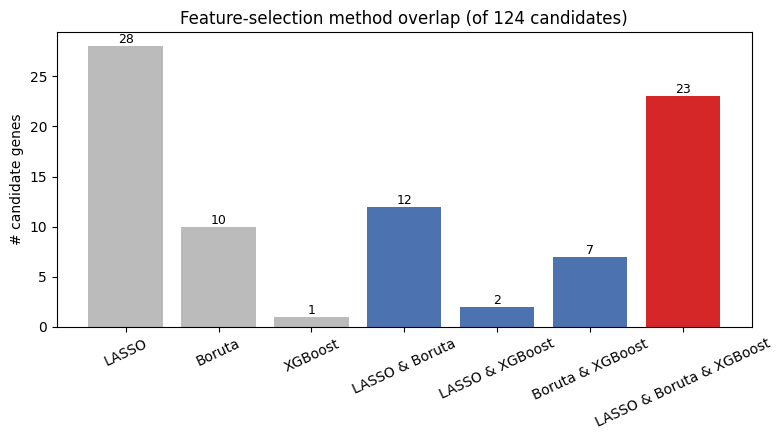

In [8]:
def combo_label(row):
    methods = [m for m in ('LASSO', 'Boruta', 'XGBoost') if row[m]]
    return ' & '.join(methods) if methods else 'none'

votes['combo'] = votes.apply(combo_label, axis=1)
combo_order = ['LASSO', 'Boruta', 'XGBoost',
               'LASSO & Boruta', 'LASSO & XGBoost', 'Boruta & XGBoost',
               'LASSO & Boruta & XGBoost']
counts = votes.loc[votes['combo'] != 'none', 'combo'].value_counts().reindex(combo_order).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#bbbbbb'] * 3 + ['#4c72b0'] * 3 + ['#d62728']
ax.bar(counts.index, counts.values, color=colors)
ax.set_ylabel('# candidate genes')
ax.set_title('Feature-selection method overlap (of 124 candidates)')
ax.tick_params(axis='x', rotation=25)
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.3, str(v), ha='center', fontsize=9)
fig.tight_layout()
fig.savefig(OUT_FIG / 'method_overlap.png', dpi=150)
plt.show()

## 8. Final gene panel, annotated

Merges the final ≥2-method panel with CellRank lineage-driver correlations and pySCENIC regulon membership for interpretability. Also splits out a `core` tier (unanimous 3/3 agreement) — see Section 9 for why.

In [9]:
final_annotated = final_panel.merge(
    overlap[['gene', 'T-FAP_1_corr', 'T-FAP_2_corr', 'regulons']], on='gene', how='left'
)
final_annotated.to_csv(OUT_DATA / 'final_panel_annotated.csv', index=False)

core_panel = final_annotated[final_annotated['n_methods'] == 3].copy()
core_panel.to_csv(OUT_DATA / 'core_panel_unanimous.csv', index=False)
print(f'{len(final_annotated)} genes at >=2/3 agreement; {len(core_panel)} of those at unanimous 3/3 agreement')
final_annotated

44 genes at >=2/3 agreement; 23 of those at unanimous 3/3 agreement


,gene,LASSO,Boruta,XGBoost,n_methods,junb_jund_klf9_target,tspc_marker,T-FAP_1_corr,T-FAP_2_corr,regulons
0,C3,True,True,True,3,True,False,0.098,0.389,Junb(+)
1,Camk2n1,True,True,True,3,True,False,0.234,-0.118,Klf9(+)
2,Cpxm1,True,True,True,3,True,False,0.290,0.180,Junb(+)
3,Fth1,True,True,True,3,True,False,0.104,0.267,Jund(+)
4,Igfbp7,True,True,True,3,True,False,0.287,0.150,Jund(+)
5,Nfib,True,True,True,3,True,False,0.395,0.046,"Junb(+), Klf9(+)"
6,Ptx3,True,True,True,3,True,False,0.121,0.392,"Junb(+), Nfkb1(+), Klf9(+)"
7,Rps29,True,True,True,3,True,False,0.246,0.113,Junb(+)
8,Scn7a,True,True,True,3,True,False,0.191,0.258,Jund(+)
9,Serping1,True,True,True,3,True,False,0.285,0.236,Junb(+)


## 9. Summary for Stage 7 (feeds Stage 8)

**Per-method yield** (of 124 candidates, 699 cells): LASSO 65 genes (10-fold CV, C=1.62), Boruta 52 confirmed (+2 tentative: Cd302, Gdf10), XGBoost 33 genes (above-mean gain importance). **≥2/3-method intersection: 44 genes** — this is the panel requested by the Stage 7 plan, applying the ≥2-of-3 rule literally.

**This exceeds the ~10–30 target range**, and that's worth reporting honestly rather than silently tightening the rule to force a fit. The likely reason: the 124-candidate pool isn't a genome-wide, mostly-noise feature space — it's already been filtered twice (pySCENIC regulon membership, then CellRank lineage-driver correlation) before any of LASSO/Boruta/XGBoost saw it, so a majority of candidates carrying real TSPC/T-FAP signal is expected, not a sign that any method is under-selective.

**Two usable tiers, both saved to `data/feature_selection/`:**
- **`final_panel_annotated.csv` (44 genes, ≥2/3 methods)** — the literal Stage 7 deliverable per the stated selection rule.
- **`core_panel_unanimous.csv` (23 genes, 3/3 methods)** — a stricter subset that does land inside the ~10–30 target, recommended as the starting panel for the Stage 8 classifier if a smaller feature set is preferred; the 44-gene panel remains available for a sensitivity/robustness pass at Stage 8.

**Notable, not designed-in:** all 5 hand-picked TSPC identity markers (Tppp3, Prg4, Igfbp6, Sema3c, Cd34) independently cleared the ≥2/3 bar — Tppp3 and Sema3c even hit unanimous 3/3 — despite none of the three methods having been told which genes were TSPC markers versus T-FAP-derived candidates. On the T-FAP side, 30/44 (68%) of the selected genes, and 14/23 (61%) of the unanimous core, are Junb/Jund/Klf9 targets (the optional weighting axis) — consistent with Stage 6's finding that these three regulons anchor most of the CellRank T-FAP driver overlap, without that fact having been used anywhere inside the three selection methods themselves.

**Caveats carried into Stage 8:** (1) no biological replicates in Harvey 2019 — CV folds here are cell-level splits within one pooled sample per condition, not independent-sample generalisation; Cherief 2023 (innervated vs. denervated) is the actual generalisation test in Stage 8. (2) Harvey's T-FAP cluster was excluded from trajectory analysis by the original paper's authors — treat T-FAP as this project's own annotation, not an externally validated cell state. (3) LASSO/Boruta/XGBoost agreement doesn't establish causal relevance to fate commitment, only that expression differs consistently between the two labelled populations across three different modelling assumptions.